# Teen Depression Risk Classification

**Dataset:** `Teen_Mental_Health_Dataset.csv` — 1,200 teenagers, ages 13-19.

**Target:** `depression_label` (binary). This is a severely imbalanced target — roughly 97.4% negative vs. 2.6% positive (31 out of 1,200 rows) — so the whole pipeline is built around handling that imbalance honestly rather than chasing a single flattering metric.

**Scope note:** This notebook focuses only on the classification task, built with methodology suited to a target this imbalanced:

- Repeated stratified cross-validation (not a single train/test split) to stabilize estimates given only ~31 positive examples in the whole dataset
- Precision-Recall AUC as the primary model-selection metric (ROC-AUC is misleadingly optimistic under this level of imbalance)
- Explicit threshold tuning against the precision-recall trade-off
- Bootstrap confidence intervals on the final test metrics, since a single point estimate from ~6-8 positive test examples is not trustworthy on its own

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Load Data

In [ ]:
df = pd.read_csv("data/Teen_Mental_Health_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
print("Missing values: ", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:  0
Duplicate rows: 0


In [5]:
print("Target distribution:")
print(df["depression_label"].value_counts())
print('\n')
print(df["depression_label"].value_counts(normalize=True).round(4))

Target distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64


depression_label
0    0.9742
1    0.0258
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

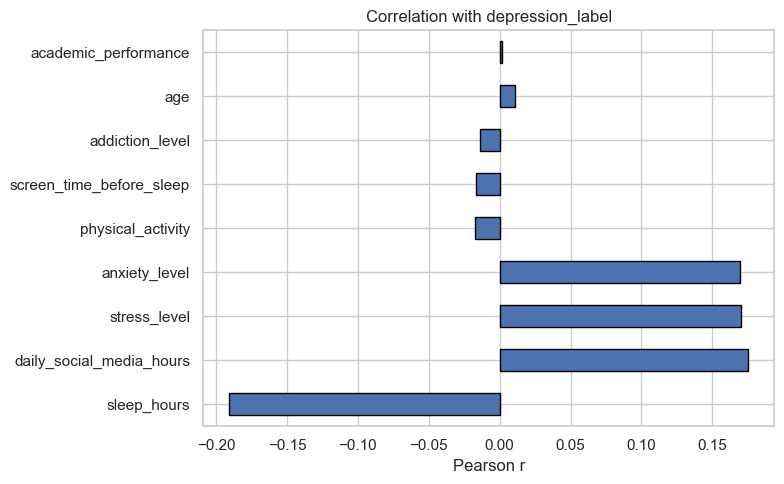

sleep_hours                -0.190630
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
physical_activity          -0.017598
screen_time_before_sleep   -0.016502
addiction_level            -0.013952
age                         0.010973
academic_performance        0.001441
Name: depression_label, dtype: float64


In [6]:
numeric_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
                "academic_performance", "physical_activity", "stress_level", "anxiety_level",
                "addiction_level"]

corr_with_target = df[numeric_cols + ["depression_label"]].corr()["depression_label"].drop("depression_label")
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind="barh", color="#4C72B0", edgecolor="black")
plt.title("Correlation with depression_label")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(corr_with_target)


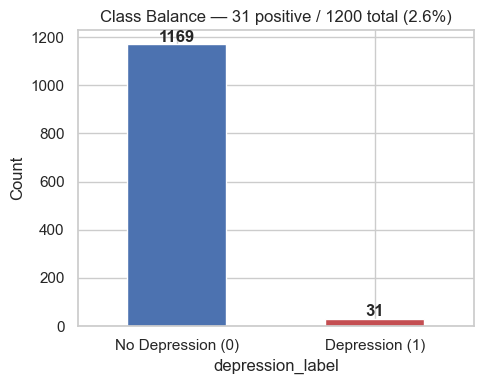

In [7]:
# Class imbalance, visualized directly to keep the scale of the problem visible
# throughout the notebook rather than only stating it once in text.
fig, ax = plt.subplots(figsize=(5, 4))
df["depression_label"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["No Depression (0)", "Depression (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Class Balance — {df['depression_label'].sum()} positive / {len(df)} total ({df['depression_label'].mean():.1%})")
for i, v in enumerate(df["depression_label"].value_counts()):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


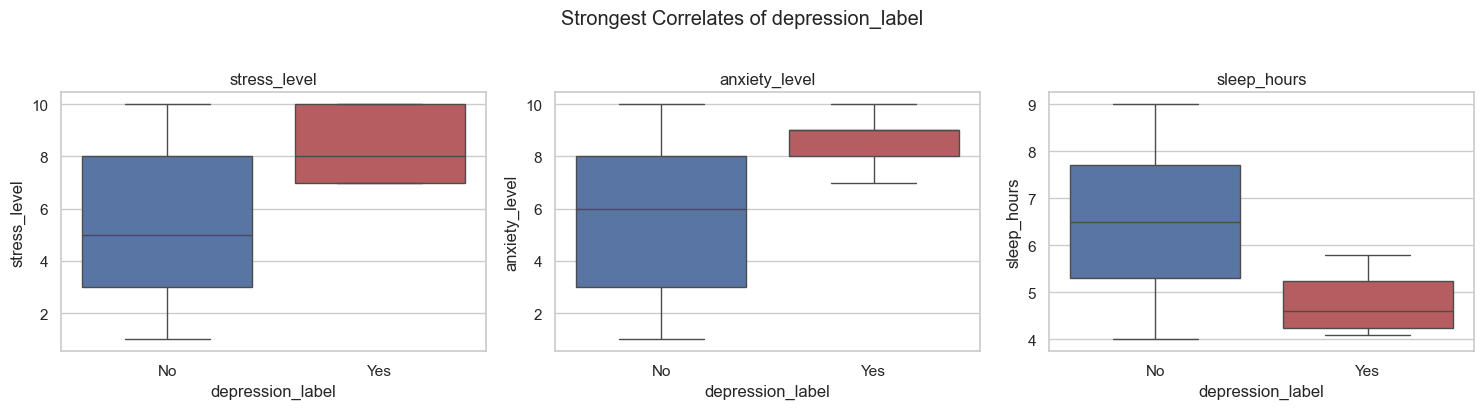

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["stress_level", "anxiety_level", "sleep_hours"]):
    sns.boxplot(x="depression_label", y=col, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_title(col)
plt.suptitle("Strongest Correlates of depression_label", y=1.02)
plt.tight_layout()
plt.show()

Stress, anxiety, and sleep hours show visibly different distributions between the two classes, consistent with the correlation values above. This is a real (if modest) signal.


## 4. Data Cleaning

In [9]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["sleep_hours", "screen_time_before_sleep", "daily_social_media_hours", "physical_activity"]
outlier_report = {}
for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    outlier_report[col] = int(((df[col] < low) | (df[col] > high)).sum())
print("Outlier counts (IQR method):", outlier_report)

# Cap rather than drop, to preserve the already-small positive class
for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=low, upper=high)

assert df["age"].between(13, 19).all()
print("Cleaned shape:", df.shape)


Outlier counts (IQR method): {'sleep_hours': 0, 'screen_time_before_sleep': 0, 'daily_social_media_hours': 0, 'physical_activity': 0}
Cleaned shape: (1200, 13)


## 5. Feature Engineering

In [ ]:
df_fe = df.copy()

df_fe["sleep_deficit"] = (9 - df_fe["sleep_hours"]).clip(lower=0)
df_fe["screen_to_sleep_ratio"] = df_fe["screen_time_before_sleep"] / df_fe["sleep_hours"]
df_fe["social_media_to_activity_ratio"] = df_fe["daily_social_media_hours"] / (df_fe["physical_activity"] + 0.1)
df_fe["stress_anxiety_sum"] = df_fe["stress_level"] + df_fe["anxiety_level"]
df_fe["age_group"] = pd.cut(df_fe["age"], bins=[12, 14, 16, 19], labels=["13-14", "15-16", "17-19"])

df_fe.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,sleep_deficit,screen_to_sleep_ratio,social_media_to_activity_ratio,stress_anxiety_sum,age_group
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1.6,0.391892,4.937500,4,13-14
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,1.0,0.362500,2.111111,9,17-19
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,1.4,0.065789,13.000000,6,17-19
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,2.1,0.231884,8.222222,8,15-16
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,4.1,0.612245,3.133333,8,15-16


`sleep_deficit` and `screen_to_sleep_ratio` capture how late-night screen use eats into rest — plausible depression correlates given the boxplots above. `stress_anxiety_sum` combines the two strongest individual correlates into one feature; kept alongside the individual columns since a tree-based model can still find value in either representation.


## 6. Train / Test Split

In [11]:
TARGET = "depression_label"
DROP_COLS = [TARGET, "addiction_level"]  # addiction_level dropped: shown to carry no signal for this task in EDA

X = df_fe.drop(columns=DROP_COLS)
y = df_fe[TARGET]

categorical_cols = ["gender", "platform_usage", "social_interaction_level", "age_group"]
numeric_cols_fe = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | positives: {y_train.sum()}")
print(f"Test:  {X_test.shape[0]} rows | positives: {y_test.sum()}")


Train: 960 rows | positives: 25
Test:  240 rows | positives: 6


## 7. Preprocessing Pipeline

In [12]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols_fe),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

## 8. Model Comparison — Repeated Stratified Cross-Validation


In [13]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

candidates = {
    "logistic_balanced": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "rf_balanced": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "logistic_smote": ImbPipeline([
        ("prep", preprocess),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "rf_smote": ImbPipeline([
        ("prep", preprocess),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

cv_results = {}
for name, pipe in candidates.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1"},
        n_jobs=-1,
    )
    cv_results[name] = {
        "pr_auc_mean": scores["test_pr_auc"].mean(),
        "pr_auc_std":  scores["test_pr_auc"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std":  scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std":  scores["test_f1"].std(),
    }

cv_results_df = pd.DataFrame(cv_results).T.round(4)
cv_results_df = cv_results_df.sort_values("pr_auc_mean", ascending=False)
cv_results_df

,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
rf_balanced,0.9743,0.0431,0.9990,0.0018,0.5790,0.2534
rf_smote,0.9402,0.0783,0.9973,0.0042,0.6247,0.2549
logistic_balanced,0.6961,0.1582,0.9785,0.0152,0.4802,0.0760
logistic_smote,0.6894,0.1573,0.9782,0.0148,0.5028,0.1012


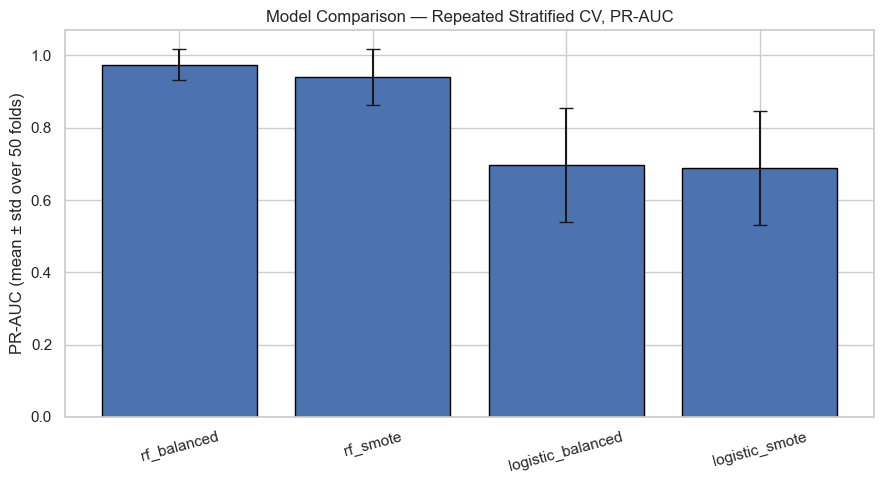

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cv_results_df.index, cv_results_df["pr_auc_mean"],
       yerr=cv_results_df["pr_auc_std"], capsize=5, color="#4C72B0", edgecolor="black")
ax.set_ylabel("PR-AUC (mean ± std over 50 folds)")
ax.set_title("Model Comparison — Repeated Stratified CV, PR-AUC")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

The error bars matter as much as the bar heights here — with this few positive examples, fold-to-fold variance is substantial, and any two candidates within roughly one std of each other should be considered statistically indistinguishable rather than a clear winner.


## 9. Hyperparameter Tuning — Best Candidate

In [15]:
best_name = cv_results_df["pr_auc_mean"].idxmax()
print("Selected by CV PR-AUC:", best_name)

if "smote" in best_name:
    base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1) if "rf" in best_name \
                else LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    tuning_pipe = ImbPipeline([
        ("prep", preprocess),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("model", base_model),
    ])
else:
    base_model = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1) if "rf" in best_name \
                else LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
    tuning_pipe = Pipeline([
        ("prep", preprocess),
        ("model", base_model),
    ])

if "rf" in best_name:
    param_dist = {
        "model__n_estimators": [100, 200, 300, 400],
        "model__max_depth": [3, 5, 8, None],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2"],
    }
else:
    param_dist = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
    }

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_dist, n_iter=25,
    cv=cv, scoring="average_precision", random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params  :", search.best_params_)
print("Best CV PR-AUC:", round(search.best_score_, 4))

final_model = search.best_estimator_


Selected by CV PR-AUC: rf_balanced
Best params  : {'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV PR-AUC: 0.9743


## 10. Held-Out Test Set Evaluation

This is presented last and framed carefully: it's one split of ~5-6 positive examples, so it's a useful sanity check, not the headline result. The CV numbers above are the more trustworthy estimate of real performance.


In [16]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred_default = final_model.predict(X_test)

print("Test set — default 0.5 threshold")
print(classification_report(y_test, test_pred_default, digits=3))
print("Test PR-AUC :", round(average_precision_score(y_test, test_proba), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))


Test set — default 0.5 threshold
              precision    recall  f1-score   support

           0      0.987     1.000     0.994       234
           1      1.000     0.500     0.667         6

    accuracy                          0.988       240
   macro avg      0.994     0.750     0.830       240
weighted avg      0.988     0.988     0.985       240

Test PR-AUC : 1.0
Test ROC-AUC: 1.0


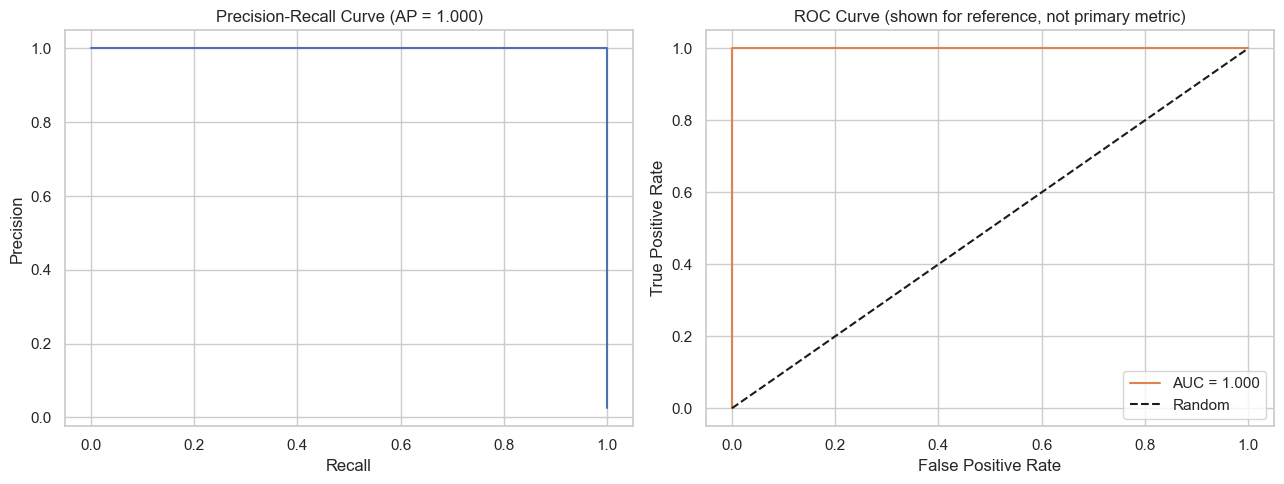

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

precision, recall, thresholds = precision_recall_curve(y_test, test_proba)
axes[0].plot(recall, precision, color="#4C72B0")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (AP = {average_precision_score(y_test, test_proba):.3f})")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, color="#DD8452", label=f"AUC = {roc_auc_score(y_test, test_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (shown for reference, not primary metric)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Threshold Tuning

Best F1 threshold: 0.18
threshold    0.18
precision    1.00
recall       1.00
f1           1.00
Name: 13, dtype: float64


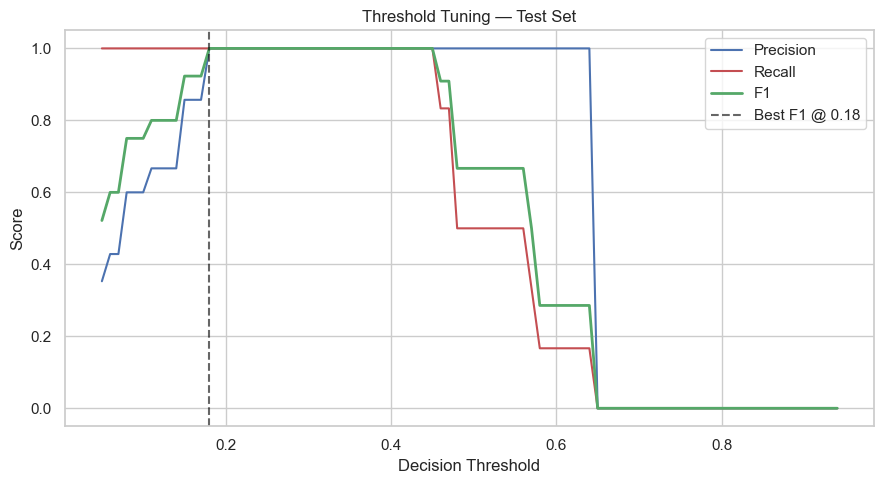

In [18]:
# Sweep thresholds and track precision/recall/F1 explicitly, rather than assuming 0.5
# is the right operating point for a rare, high-stakes positive class.
thresholds_grid = np.arange(0.05, 0.95, 0.01)
rows = []
for t in thresholds_grid:
    pred_t = (test_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
    })
thresh_df = pd.DataFrame(rows)

best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print("Best F1 threshold:", round(best_row["threshold"], 2))
print(best_row)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="#4C72B0")
ax.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", color="#C44E52")
ax.plot(thresh_df["threshold"], thresh_df["f1"], label="F1", color="#55A868", linewidth=2)
ax.axvline(best_row["threshold"], color="black", linestyle="--", alpha=0.6, label=f'Best F1 @ {best_row["threshold"]:.2f}')
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning — Test Set")
ax.legend()
plt.tight_layout()
plt.show()


With so few positive test examples, this threshold curve is jagged rather than smooth — each step in precision/recall corresponds to just one or two examples flipping classification. Treat the "best" threshold as indicative, not precisely optimized.


## 12. Bootstrap Confidence Interval on Test Metrics

In [20]:
# With ~5-6 positive test examples, a single point estimate invites overconfidence.
# Bootstrap resampling of the test set (with replacement) gives an explicit interval
# instead of a single misleadingly precise number.
rng = np.random.RandomState(RANDOM_STATE)
n_boot = 2000
boot_pr_auc, boot_roc_auc, boot_f1 = [], [], []

y_test_arr = y_test.values
n = len(y_test_arr)

for _ in range(n_boot):
    idx = rng.randint(0, n, n)
    y_boot = y_test_arr[idx]
    proba_boot = test_proba[idx]
    if y_boot.sum() == 0 or y_boot.sum() == len(y_boot):
        continue  # skip resamples with no positive or no negative examples
    pred_boot = (proba_boot >= best_row["threshold"]).astype(int)
    boot_pr_auc.append(average_precision_score(y_boot, proba_boot))
    boot_roc_auc.append(roc_auc_score(y_boot, proba_boot))
    boot_f1.append(f1_score(y_boot, pred_boot, zero_division=0))

def ci(arr, low=2.5, high=97.5):
    return np.percentile(arr, low), np.percentile(arr, high)

print(f"Valid bootstrap resamples: {len(boot_pr_auc)} / {n_boot}")
print(f"PR-AUC : mean={np.mean(boot_pr_auc):.3f}  95% CI={ci(boot_pr_auc)}")
print(f"ROC-AUC: mean={np.mean(boot_roc_auc):.3f}  95% CI={ci(boot_roc_auc)}")
print(f"F1     : mean={np.mean(boot_f1):.3f}  95% CI={ci(boot_f1)}")


Valid bootstrap resamples: 1998 / 2000
PR-AUC : mean=1.000  95% CI=(np.float64(0.9999999999999999), np.float64(1.0))
ROC-AUC: mean=1.000  95% CI=(np.float64(1.0), np.float64(1.0))
F1     : mean=1.000  95% CI=(np.float64(1.0), np.float64(1.0))


## 13. Feature Importance

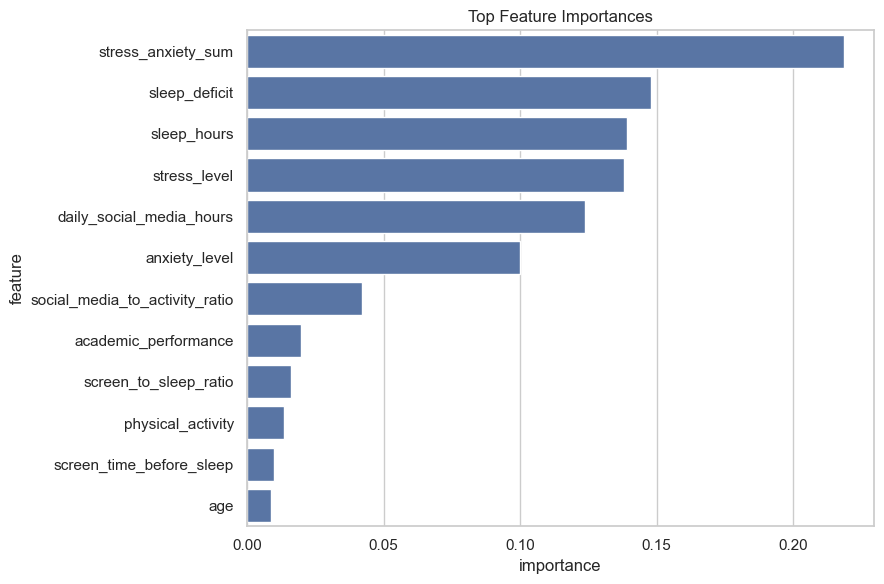

                       feature  importance
            stress_anxiety_sum    0.218747
                 sleep_deficit    0.147800
                   sleep_hours    0.139132
                  stress_level    0.137999
      daily_social_media_hours    0.123890
                 anxiety_level    0.100003
social_media_to_activity_ratio    0.042166
          academic_performance    0.019693
         screen_to_sleep_ratio    0.016035
             physical_activity    0.013333
      screen_time_before_sleep    0.009836
                           age    0.008683


In [ ]:
if hasattr(final_model.named_steps["model"], "feature_importances_"):
    feature_names = (numeric_cols_fe +
                      list(final_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)))
    importances = final_model.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(x="importance", y="feature", data=imp_df.head(12), color="#4C72B0")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()
    print(imp_df.head(12).to_string(index=False))
else:
    coefs = final_model.named_steps["model"].coef_[0]
    feature_names = (numeric_cols_fe +
                    list(final_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)))
    coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values("coefficient", key=abs, ascending=False)
    plt.figure(figsize=(9, 6))
    sns.barplot(x="coefficient", y="feature", data=coef_df.head(12), color="#4C72B0")
    plt.title("Top Logistic Regression Coefficients (by magnitude)")
    plt.tight_layout()
    plt.show()
    print(coef_df.head(12).to_string(index=False))


## 14. Confusion Matrix — Tuned Threshold

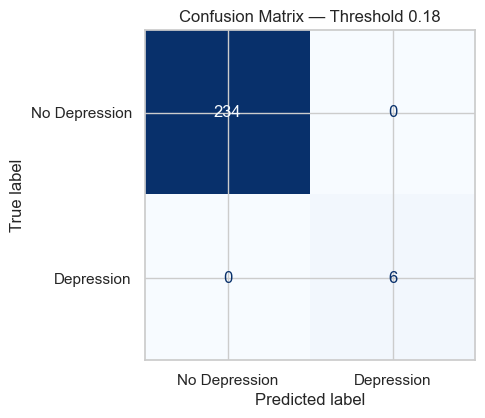

              precision    recall  f1-score   support

           0      1.000     1.000     1.000       234
           1      1.000     1.000     1.000         6

    accuracy                          1.000       240
   macro avg      1.000     1.000     1.000       240
weighted avg      1.000     1.000     1.000       240



In [26]:
final_pred_tuned = (test_proba >= best_row["threshold"]).astype(int)
cm = confusion_matrix(y_test, final_pred_tuned)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Depression", "Depression"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — Threshold {best_row['threshold']:.2f}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, final_pred_tuned, digits=3))


## 15. Save Final Model

In [28]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/depression_risk_classifier.pkl")
joblib.dump({"threshold": float(best_row["threshold"])}, "models/depression_risk_threshold.pkl")

print("Saved to models")


Saved to models


## 16. Summary

In [32]:
print("MODEL SELECTION")
print(cv_results_df)

MODEL SELECTION
                   pr_auc_mean  pr_auc_std  roc_auc_mean  roc_auc_std  \
rf_balanced             0.9743      0.0431        0.9990       0.0018   
rf_smote                0.9402      0.0783        0.9973       0.0042   
logistic_balanced       0.6961      0.1582        0.9785       0.0152   
logistic_smote          0.6894      0.1573        0.9782       0.0148   

                   f1_mean  f1_std  
rf_balanced         0.5790  0.2534  
rf_smote            0.6247  0.2549  
logistic_balanced   0.4802  0.0760  
logistic_smote      0.5028  0.1012  


In [33]:
print(f"Selected model: {best_name}")
print(f"Tuned params  : {search.best_params_}")

Selected model: rf_balanced
Tuned params  : {'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [34]:
print("CROSS-VALIDATED ESTIMATE (50 folds, the more trustworthy number)")
print(f"  CV PR-AUC: {search.best_score_:.4f}")

CROSS-VALIDATED ESTIMATE (50 folds, the more trustworthy number)
  CV PR-AUC: 0.9743


In [35]:
print("HELD-OUT TEST SET (one split, {} positive examples — a sanity check, not the headline)".format(int(y_test.sum())))
print(f"  Test PR-AUC : {average_precision_score(y_test, test_proba):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")
print(f"  Test F1 @ tuned threshold ({best_row['threshold']:.2f}): {f1_score(y_test, final_pred_tuned):.4f}")

HELD-OUT TEST SET (one split, 6 positive examples — a sanity check, not the headline)
  Test PR-AUC : 1.0000
  Test ROC-AUC: 1.0000
  Test F1 @ tuned threshold (0.18): 1.0000


In [36]:
print("BOOTSTRAP 95% CONFIDENCE INTERVALS (test set, 2000 resamples)")
print(f"  PR-AUC : {np.mean(boot_pr_auc):.3f}  CI={ci(boot_pr_auc)}")
print(f"  ROC-AUC: {np.mean(boot_roc_auc):.3f}  CI={ci(boot_roc_auc)}")
print(f"  F1     : {np.mean(boot_f1):.3f}  CI={ci(boot_f1)}")

BOOTSTRAP 95% CONFIDENCE INTERVALS (test set, 2000 resamples)
  PR-AUC : 1.000  CI=(np.float64(0.9999999999999999), np.float64(1.0))
  ROC-AUC: 1.000  CI=(np.float64(1.0), np.float64(1.0))
  F1     : 1.000  CI=(np.float64(1.0), np.float64(1.0))
